In [1]:
import platform
platform.platform()

'macOS-26.2-arm64-arm-64bit'

In [2]:
import sys
sys.version

'3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]'

In [3]:
import os
sys.path.append(os.path.abspath("../../.."))

In [4]:
import matplotlib
matplotlib.__version__

'3.10.8'

In [5]:
import matplotlib.pyplot as plt

In [6]:
import numpy as np
np.__version__

'1.23.5'

In [7]:
import pandas as pd
pd.__version__

'2.3.3'

In [8]:
import scipy
scipy.__version__

'1.15.3'

In [9]:
import sklearn
sklearn.__version__

'1.3.0'

In [10]:
from sklearn.decomposition import PCA

In [11]:
from SSMetrics import metrics

In [12]:
df1 = pd.read_csv("../../../1_dataset/1_28descriptors/3_PCA/pca.csv")
df1.shape

(4665, 39)

In [13]:
df1.columns

Index(['SMILES', 'InChI', 'InChIKey', 'K3FeCN6', 'MesAcr+BF4-', 'CuCl',
       'Diacetyl', 'T(p-OMe)PPCo', 'Electrode', 'm_1_L', 'm_1_B1', 'm_1_B5',
       'p_L', 'p_B1', 'p_B5', 'm_2_L', 'm_2_B1', 'm_2_B5', 'o_L', 'o_B1',
       'o_B5', 'Charge_O', 'Charge_next_O', 'Charge_o_1', 'Charge_m_1',
       'Charge_p', 'Charge_m_2', 'Charge_o_2', 'HOMO', 'MolLogP', 'MolWt',
       'num_N', 'num_O', 'num_S', 'num_F', 'num_Cl', 'num_Br', 'PC1', 'PC2'],
      dtype='object')

In [14]:
conditions = [["K3FeCN6",(255/255, 75/255, 0/255), "K$_3$[Fe(CN)$_6$]"],
              ["MesAcr+BF4-", (153/255, 0/255, 153/255), "MesAcr$^+$BF$_4^-$"],
              ["CuCl", (3/255, 175/255, 122/255), "CuCl"],
              ["Diacetyl", (246/255, 170/255, 0/255), "Diacetyl"],
              ["T(p-OMe)PPCo", (77/255, 196/255, 255/255), "T($p$-OMe)PPCo"],
              ["Electrode", (255/255, 128/255, 130/255), "Electrode"]]

In [15]:
li_numbers = []
li_ratio = [32.59724624656359]

li_2d = []
li_3d = []
li_4d = []
li_5d = []
li_6d = []
li_7d = []
li_8d = []


In [16]:
df2 = df1.loc[:, "m_1_L" : "num_Br"]

In [17]:
def calc_d(li, n_components, number):
    pca = PCA(n_components=n_components, whiten=True)
    pca.fit(df2)

    df_score = pd.DataFrame(
        pca.transform(df2),
        columns=[f"PC{i}" for i in range(1, n_components+1)]
        )
    df_pca = pd.concat([df1.loc[:, "SMILES":"Electrode"], df_score], axis=1)

    ratio = pca.explained_variance_ratio_
    ans = 0
    for i in range(n_components):
        ans += ratio[i]
    li_ratio.append(ans*100)

    for i in range(6):
        condition = conditions[i][0]
        print(f"{condition}, {n_components}D")

        df = df_pca[df_pca[condition] == 1].loc[:, "PC1":f"PC{n_components}"]
        
        if number:
            li_numbers.append(len(df))

        array = df.to_numpy()
        area, _ = metrics.metrics_ConvexHull(array)
        li.append(area)

        print(f"ConvexHull: {area}\n")
    

In [18]:
calc_d(li_2d, 2, True)
calc_d(li_3d, 3, False)
calc_d(li_4d, 4, False)
calc_d(li_5d, 5, False)
calc_d(li_6d, 6, False)
calc_d(li_7d, 7, False)
calc_d(li_8d, 8, False)

K3FeCN6, 2D
ConvexHull: 4.143509598043828

MesAcr+BF4-, 2D
ConvexHull: 6.430956341160752

CuCl, 2D
ConvexHull: 3.5159039457424295

Diacetyl, 2D
ConvexHull: 4.459198482988258

T(p-OMe)PPCo, 2D
ConvexHull: 3.2207955272984625

Electrode, 2D
ConvexHull: 3.6293113947129974

K3FeCN6, 3D
ConvexHull: 3.2075129901450503

MesAcr+BF4-, 3D
ConvexHull: 7.5016410127510955

CuCl, 3D
ConvexHull: 1.965256743368369

Diacetyl, 3D
ConvexHull: 3.967420316329568

T(p-OMe)PPCo, 3D
ConvexHull: 1.3168930834419001

Electrode, 3D
ConvexHull: 2.69828754295954

K3FeCN6, 4D
ConvexHull: 1.4781331834474682

MesAcr+BF4-, 4D
ConvexHull: 6.561772281824767

CuCl, 4D
ConvexHull: 0.8062728137036033

Diacetyl, 4D
ConvexHull: 1.944156013178268

T(p-OMe)PPCo, 4D
ConvexHull: 0.3122087299351877

Electrode, 4D
ConvexHull: 0.7343931036268172

K3FeCN6, 5D
ConvexHull: 1.1179874797679843

MesAcr+BF4-, 5D
ConvexHull: 4.578613105627228

CuCl, 5D
ConvexHull: 0.38870195296525867

Diacetyl, 5D
ConvexHull: 0.931310955036759

T(p-OMe)PPCo,

In [19]:
labels = []

for i in range(6):
    labels.append(f"{conditions[i][2]} ({li_numbers[i]})")
    
labels

['K$_3$[Fe(CN)$_6$] (23)',
 'MesAcr$^+$BF$_4^-$ (20)',
 'CuCl (19)',
 'Diacetyl (12)',
 'T($p$-OMe)PPCo (9)',
 'Electrode (9)']

In [20]:
df_result = pd.DataFrame({"Condition": [e[0] for e in conditions],
                          "Number":li_numbers})

df_result[f"2\n({li_ratio[0]:.2f}%)"] = li_2d
df_result[f"3\n({li_ratio[1]:.2f}%)"] = li_3d
df_result[f"4\n({li_ratio[2]:.2f}%)"] = li_4d
df_result[f"5\n({li_ratio[3]:.2f}%)"] = li_5d
df_result[f"6\n({li_ratio[4]:.2f}%)"] = li_6d
df_result[f"7\n({li_ratio[5]:.2f}%)"] = li_7d
df_result[f"8\n({li_ratio[6]:.2f}%)"] = li_8d


df_result

,Condition,Number,2\n(32.60%),3\n(32.60%),4\n(42.70%),5\n(51.12%),6\n(57.86%),7\n(62.87%),8\n(67.11%)
0,K3FeCN6,23,4.143510,3.207513,1.478133,1.117987,0.567798,0.212870,0.021829
1,MesAcr+BF4-,20,6.430956,7.501641,6.561772,4.578613,3.455490,1.666732,0.479283
2,CuCl,19,3.515904,1.965257,0.806273,0.388702,0.127845,0.021117,0.001604
3,Diacetyl,12,4.459198,3.967420,1.944156,0.931311,0.194536,0.019685,0.001069
4,T(p-OMe)PPCo,9,3.220796,1.316893,0.312209,0.176778,0.027532,0.002263,0.000043
5,Electrode,9,3.629311,2.698288,0.734393,0.287471,0.135431,0.018168,0.002767


In [21]:
df_result.to_csv("si_ConvexHull.csv", index=False)

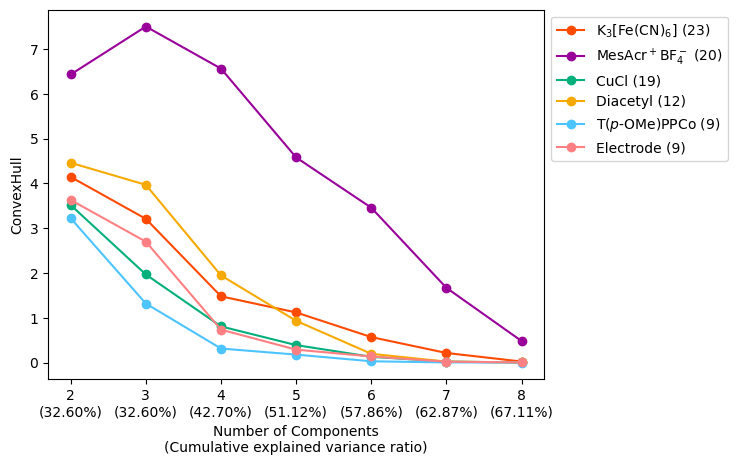

In [22]:
fig = plt.figure()
ax = fig.add_subplot()

for i in range(6):
    ax.plot(
        df_result.iloc[i, 2:],
        marker="o",
        color=conditions[i][1],
        label=labels[i]
        )

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.set_xlabel("Number of Components\n(Cumulative explained variance ratio)")
ax.set_ylabel("ConvexHull")

plt.savefig("si_ConvexHull.png", dpi=300, bbox_inches="tight")
plt.show()